In [1]:
import qutip as qt
import numpy as np
import scipy as sp
import matplotlib
import matplotlib.pyplot as plt
import os
import math
from itertools import combinations

#plt.rcParams['text.usetex'] = True
#rfont = {'fontname':'Times New Roman'}
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

# Spin matrix
S0 = qt.qeye(3)                                                # {1, 0, -1}
Sx, Sy, Sz = qt.jmat(1)                                        # {1, 0, -1}
sigma0 = qt.qeye(2)                                            # {Ex, Ey}
sigmax, sigmay, sigmaz = qt.sigmax(), qt.sigmay(), qt.sigmaz() # {Ex, Ey}

# Physics constant
h             = 6.626e-34        # J/Hz
muB           = 9.274e-24 / h    # Hz/T
Des_para      = 1.42e9           # Hz       # [Doherty 2013], 1.44e9[Bassett 2014] 
Des_perp      = 1.55e9/2         # Hz       # [Doherty 2013], 1.541e9[Bassett 2014] 
lambdaes_para = 5.3e9            # Hz       # [Doherty 2013], 5.33e9[Bassett 2014]
lambdaes_perp = 0.2e9/np.sqrt(2) # Hz       # [Doherty 2013]
des_para      = 6e3              # Hz/(V/m) # [Doherty 2013]?
des_perp      = 6e3              # Hz/(V/m) # [Doherty 2013]?
les_para      = 0.1              # 1        # [Doherty 2013], 0.05[Bassett 2014] at 1.5K
ges_para      = 2.01             # 1        # [Doherty 2013], 2.15[Bassett 2014]
ges_perp      = 2.01             # 1        # [Doherty 2013]
gamma_e       = muB * ges_para

We difine Hamiltonian in excited state as the below

In [2]:
# bare Hamiltonian
H_es = Des_para * qt.tensor(sigma0, Sz**2 - 2/3 * S0) \
       - lambdaes_para * qt.tensor(sigmay, Sz) \
       + Des_perp * (qt.tensor(sigmaz, Sy**2 - Sx**2) - qt.tensor(sigmax, Sy * Sx + Sx * Sy)) \
       + lambdaes_perp * (qt.tensor(sigmaz, Sx * Sz + Sz * Sx) - qt.tensor(sigmax, Sy * Sz + Sz * Sy))

# Interaction Hamiltonian
def V_es(E, B, delta):
    return des_para * (E[2] + delta[2]) * qt.tensor(sigma0, S0) \
           + des_perp * (E[0] + delta[0]) * qt.tensor(sigmaz, S0) \
           - des_perp * (E[1] + delta[1]) * qt.tensor(sigmax, S0) \
           + muB * (les_para * qt.tensor(sigmay, S0) + ges_para * qt.tensor(sigma0, Sz)) * B[2] \
           + muB * ges_perp * qt.tensor(sigma0, Sx * B[0] + Sy * B[1])


### stream line

1. Decpmpose eigenstates besed on spin basis
2. Extracting the amplitude coresponded to spin basis, resoectuvily
3. Define condition value ,Xi, which can reflect how spin basis are mixed , 
4. plot the normalized Xi  , sweeping magneticfield(para) and strain(perp)

In [3]:
# Decompostion of eigenstates based on spin basis
def Decomposition(H_tot):
    ee, ev = H_tot.eigenstates()
    ev_amp = [abs(evi.full()) for evi in ev][::-1]

    return ev_amp


# condition value
def Xi(List,i,j):
    a_i = List[i-1]
    a_j = List[j-1]

    return ( abs( abs(a_i)-abs(a_j) ) )/(abs(a_i) + abs(a_j) )

def Xi_pro(List, i, j):
    a_i = List[i-1]
    a_j = List[j-1]

    return (abs(a_i))**2 * (abs(a_j))**2

# extraction fot key 
def get_key_from_value(d, val):
    keys = [k for k, v in d.items() if v == val]
    if keys:
        return keys[0]
    return None

# Ductionary of ES and spin basis
Es = {'|A_2>': 0,'|A_1>': 1,'|E_x>': 2,'|E_y>': 3,'|E_1>': 4,'|E_2>': 5 }
spin_basis_labels = ['|E_x,+1⟩', '|E_x,0⟩', '|E_x,-1⟩', '|E_y,+1⟩', '|E_y,0⟩', '|E_y,-1⟩']


key1 = get_key_from_value(Es, 1)

In [4]:

# mapping function 
def map_spin_fun_Xi(Number_Es):
    # Meshgrid parameters
    E = [0, 0, 0]
    strain_perp_values = np.linspace(0, 60e9, 1000)
    Bz_values = np.linspace(0, 5000e-4, 1000)

    # Allocate result matrix for score 
    score_map = np.zeros((len(strain_perp_values), len(Bz_values)))

    # Evaluate 1/diff over parameter space
    for k, strain_perp in enumerate(strain_perp_values):
        deltax = deltay = strain_perp / np.sqrt(2) / des_perp
        strain = [deltax, deltay, 0]

        for w, Bz in enumerate(Bz_values):
            B = [0, 0, Bz]
            H_tot = H_es + V_es(E, B, strain)

            amp_list = Decomposition(H_tot)[Number_Es]  

            score = 0.0

            for i in range(6):

                for j in range(i+1,6):
                    diff = Xi(amp_list, i, j)           # Xi between i and j components
                    # To avoid dividing by very small numbers, clamp diff
                    if diff < 1e-2:
                        diff = 1e-2
                    score += (1e9/diff)
            score_map[k, w] = math.log10(score)


    # converting spin_number => ES
    E_state = get_key_from_value(Es, Number_Es)
    
    # Plotting the heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(score_map, extent=[Bz_values[0]*1e3, Bz_values[-1]*1e3,
                                  strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9],
               origin='lower', aspect='auto', cmap='viridis')

    plt.colorbar(label='score')
    plt.xlabel('Bz (mT)')
    plt.ylabel('Strain_perp (GHz)')
    plt.title('Mixture of spin basis in %s'  %(E_state))
    plt.tight_layout()
    plt.show()

In [4]:

# mapping function 
def map_spin_fun_Xi_pro(Number_Es):
    # Meshgrid parameters
    E = [0, 0, 0]
    strain_perp_values = np.linspace(0, 60e9, 1000)
    Bz_values = np.linspace(0, 5000e-4, 1000)

    # Allocate result matrix for score 
    score_map = np.zeros((len(strain_perp_values), len(Bz_values)))

    # Evaluate 1/diff over parameter space
    for k, strain_perp in enumerate(strain_perp_values):
        deltax = deltay = strain_perp / np.sqrt(2) / des_perp
        strain = [deltax, deltay, 0]

        for w, Bz in enumerate(Bz_values):
            B = [0, 0, Bz]
            H_tot = H_es + V_es(E, B, strain)

            amp_list = Decomposition(H_tot)[Number_Es]  

            score = 0.0

            for i in range(6):
                for j in range(i+1,6):
                    diff = Xi_pro(amp_list, i, j)/0.25
                    score += diff
            score_map[k, w] = score


    # converting spin_number => ES
    E_state = get_key_from_value(Es, Number_Es)
    
    # Plotting the heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(score_map, extent=[Bz_values[0]*1e3, Bz_values[-1]*1e3,
                                  strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9],
               origin='lower', aspect='auto', cmap='viridis', 
               vmin=0, vmax=15)

    plt.colorbar(label='score')
    plt.xlabel('Bz (mT)')
    plt.ylabel('Strain_perp (GHz)')
    plt.title('Mixture of spin basis in %s'  %(E_state))
    plt.tight_layout()
    plt.show()

In [7]:
#{'|A_2>': 0,'|A_1>': 1,'|E_x>': 2,'|E_y>': 3,'|E_1>': 4,'|E_2>': 5 }
map_spin_fun_Xi(1)
map_spin_fun_Xi_pro(1)

C:\Users\risei\AppData\Local\Temp\ipykernel_9576\3050518347.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = math.log10(score)


KeyboardInterrupt: 

C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_26976\3050518347.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = math.log10(score)


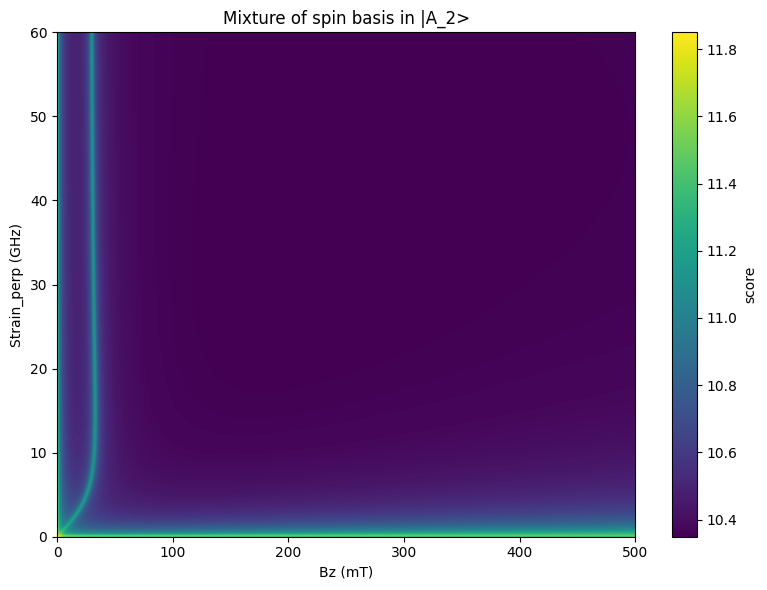

C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_26976\3917670560.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = score


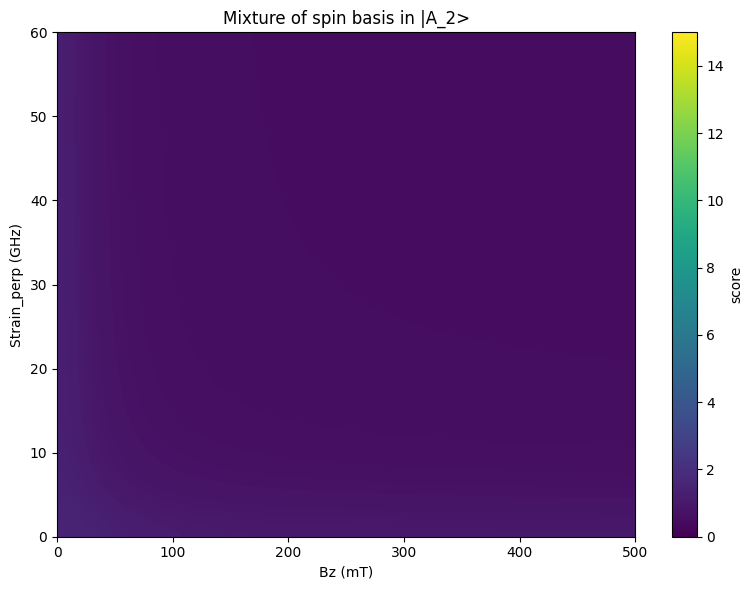

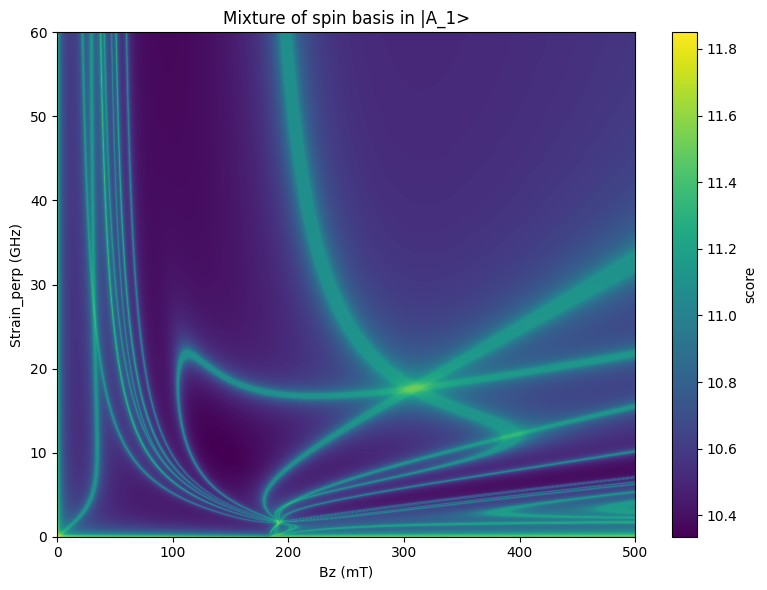

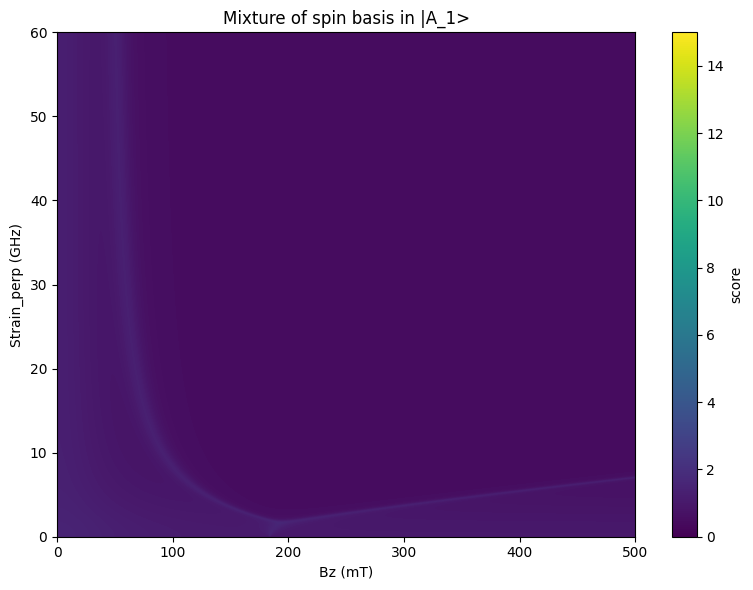

C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_26976\3415232365.py:14: RuntimeWarning: invalid value encountered in divide
  return ( abs( abs(a_i)-abs(a_j) ) )/(abs(a_i) + abs(a_j) )


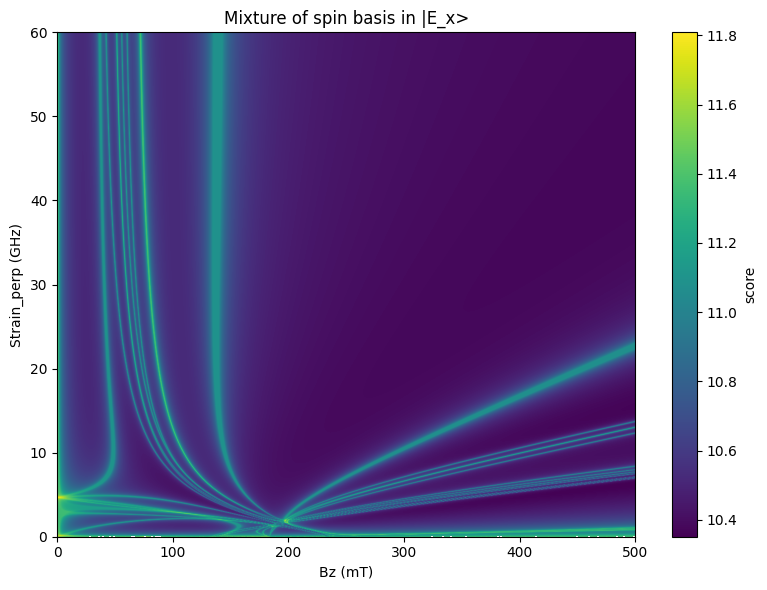

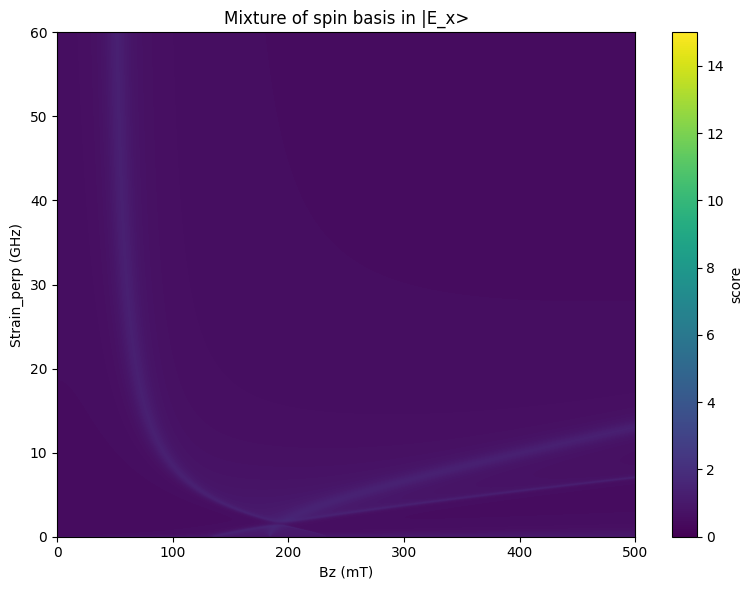

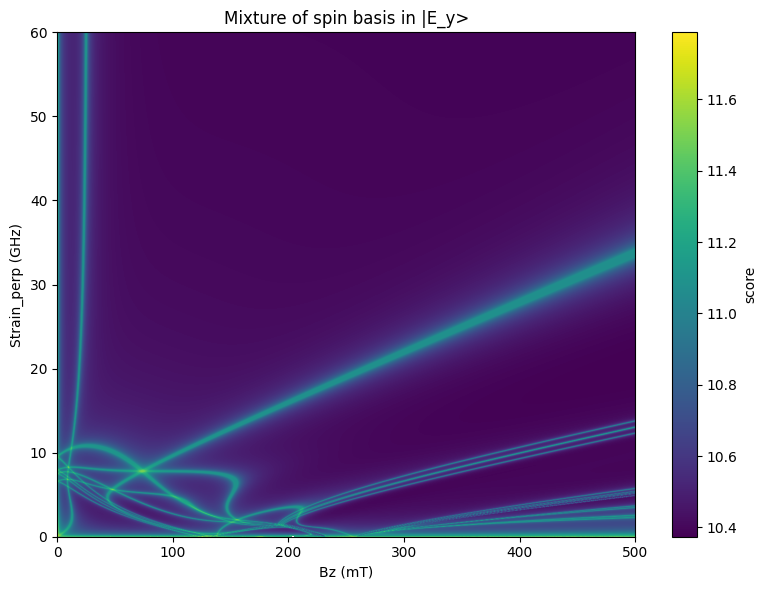

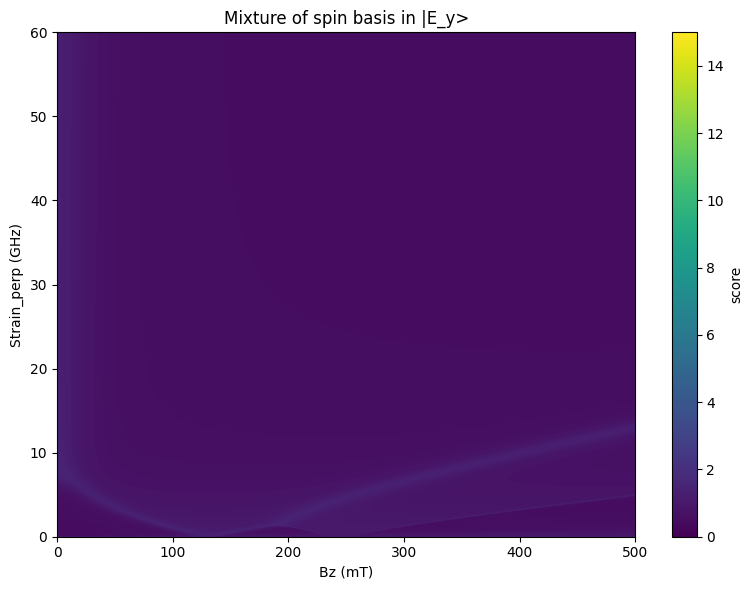

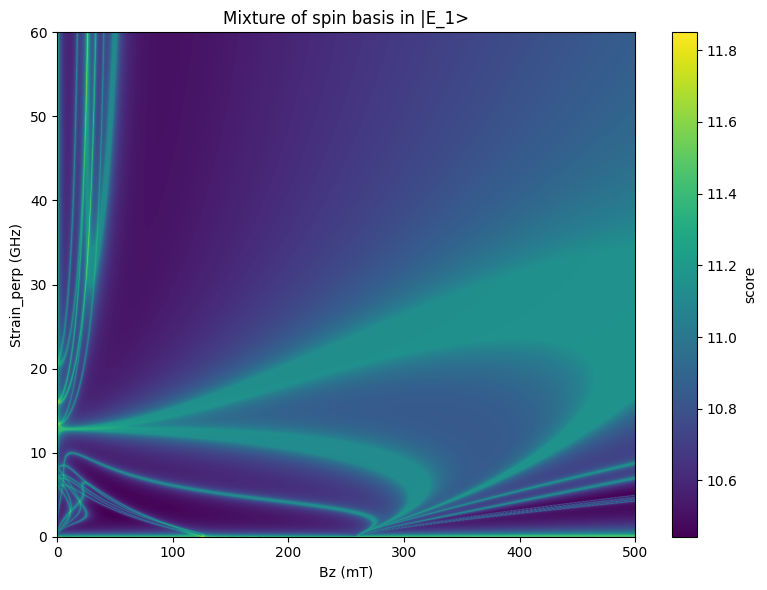

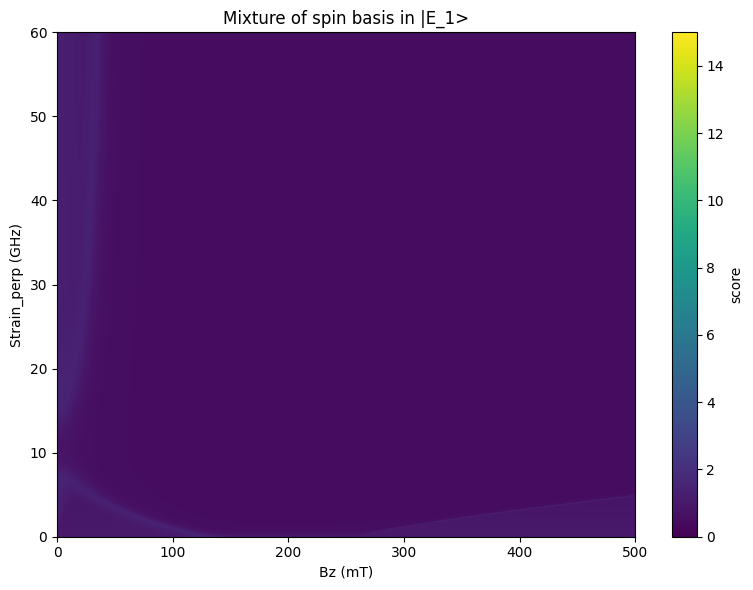

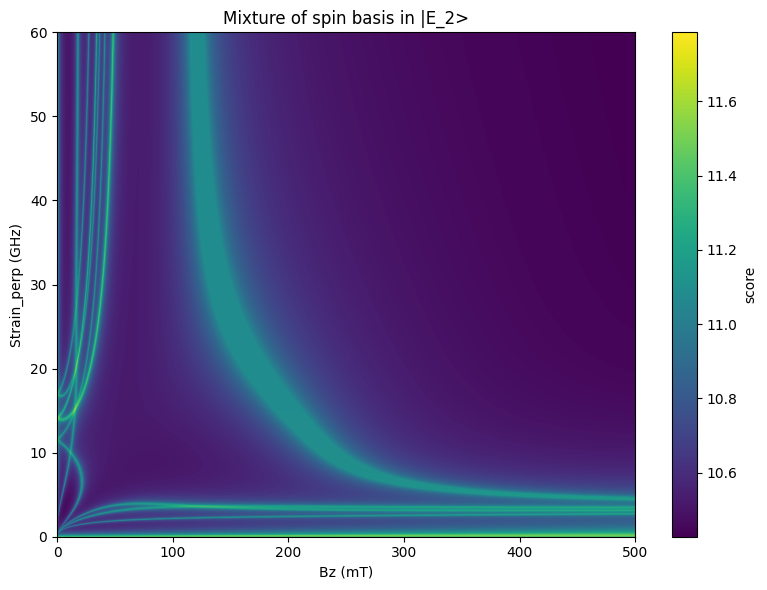

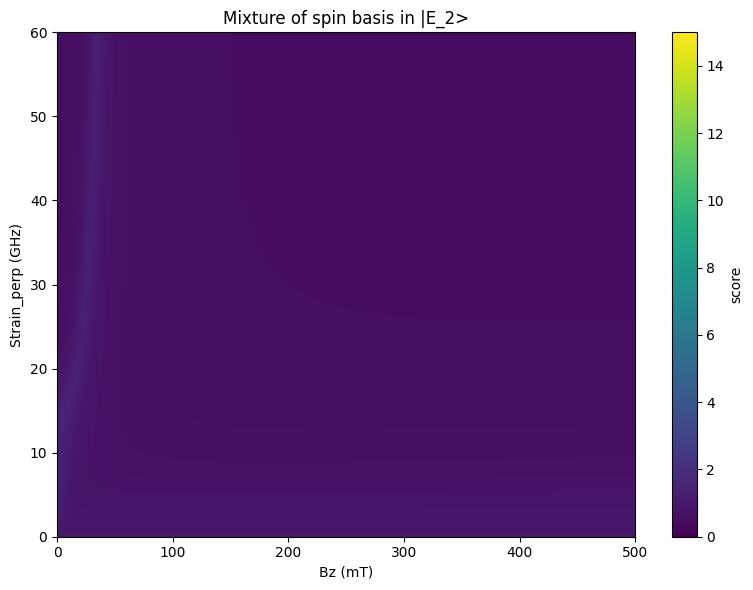

In [18]:

for spin_basis in range(6):
    map_spin_fun_Xi(spin_basis)
    map_spin_fun_Xi_pro(spin_basis)

In [ ]:
for spinbasis in range(6):
    map_spin_fun_Xi_pro(spinbasis) 

<>:32: SyntaxWarning: invalid escape sequence '\d'
<>:32: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_5824\1829188400.py:32: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('Transverse strain $\delta_\perp$ (GHz)')
C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_5824\1829188400.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = score


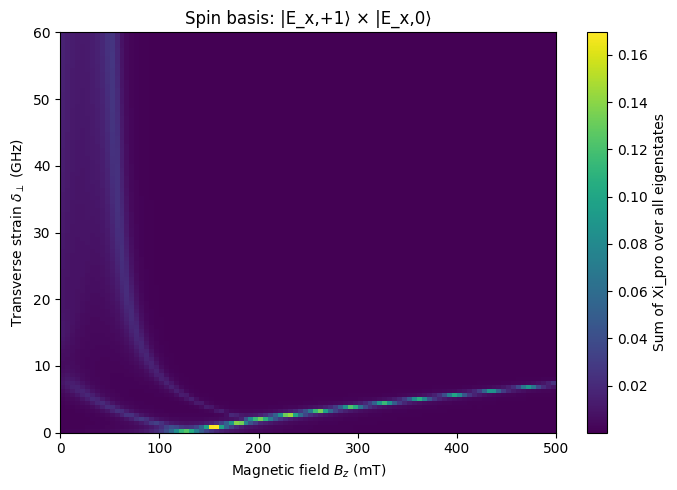

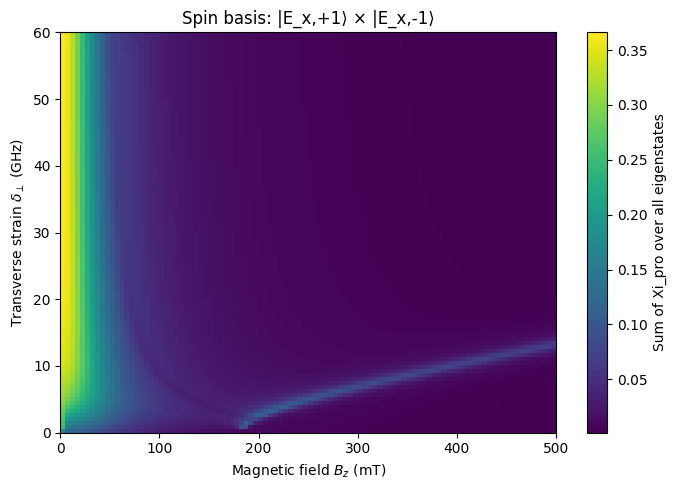

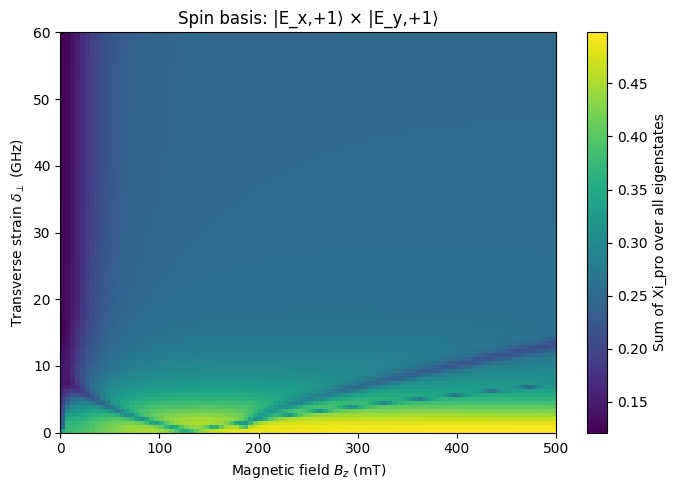

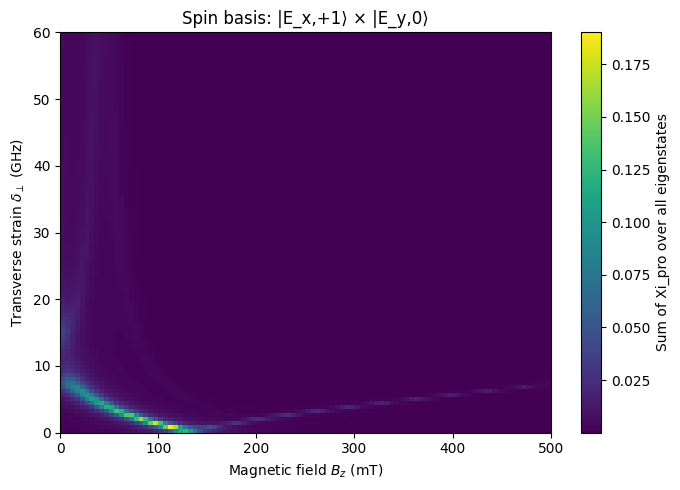

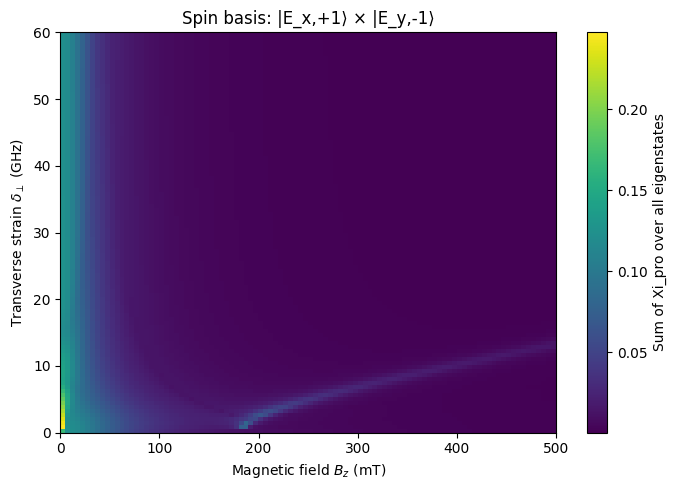

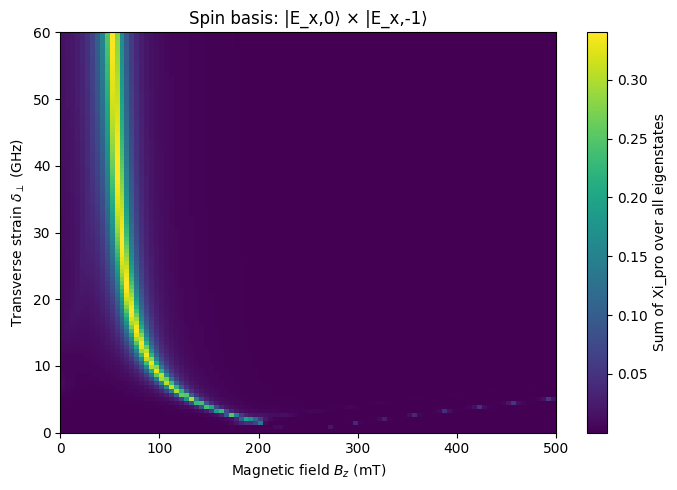

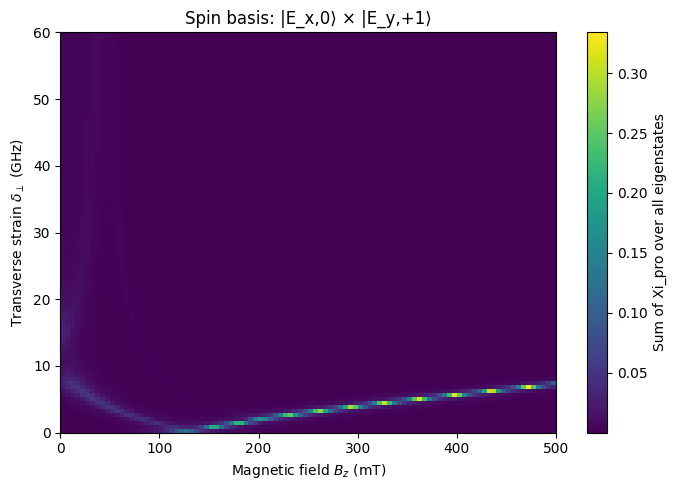

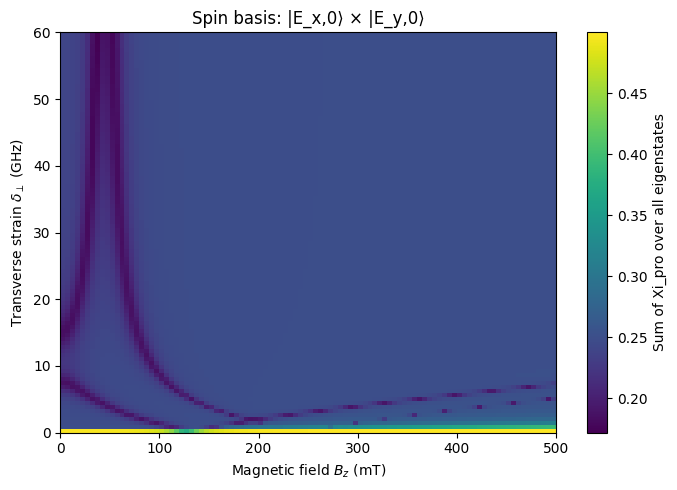

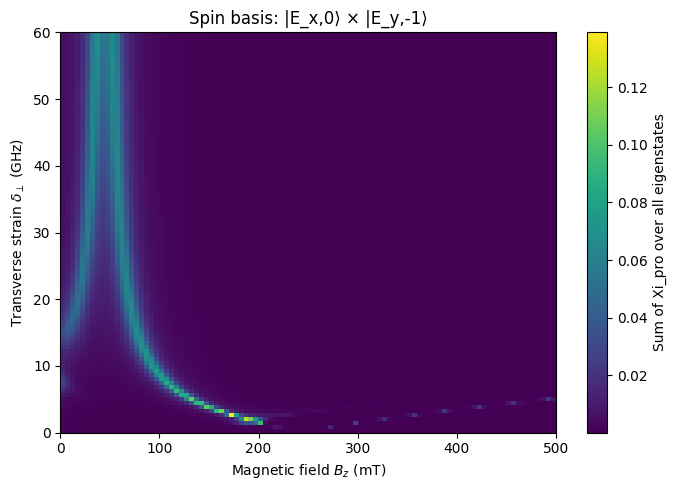

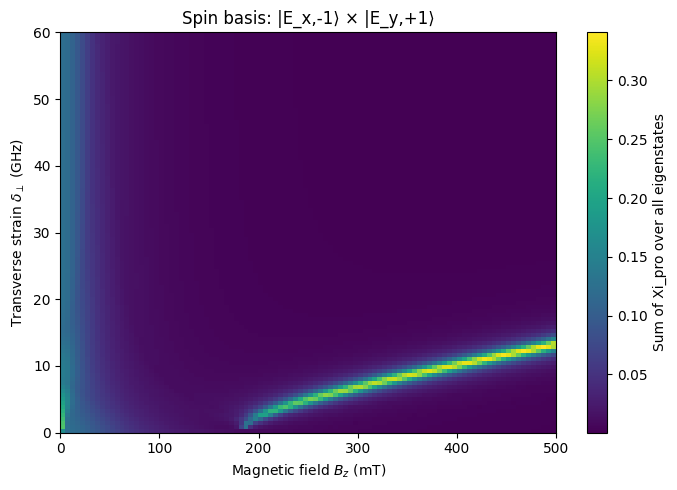

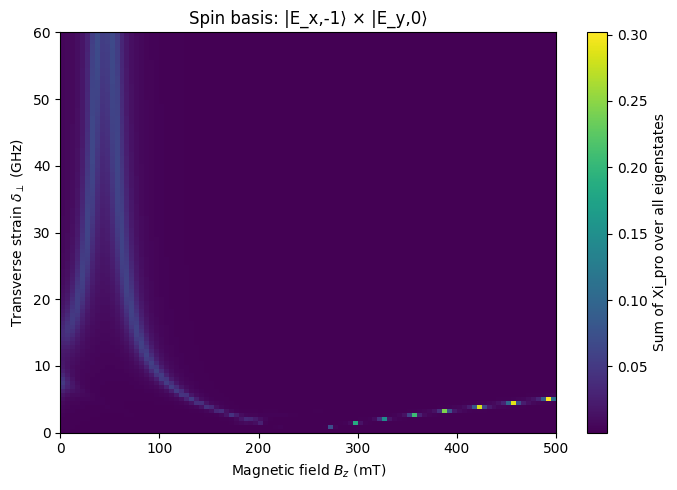

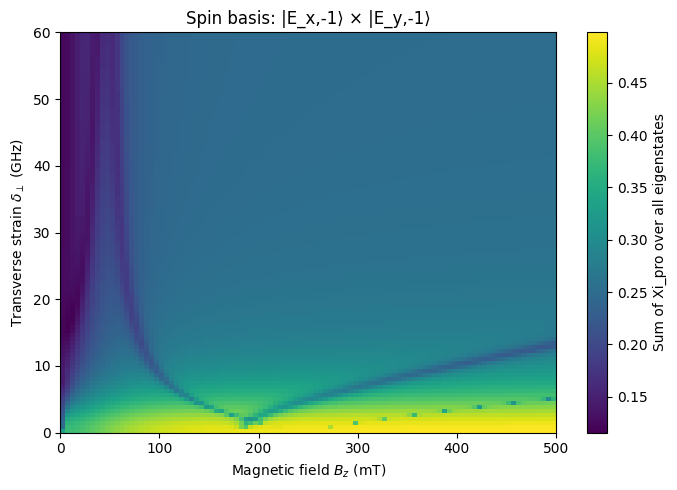

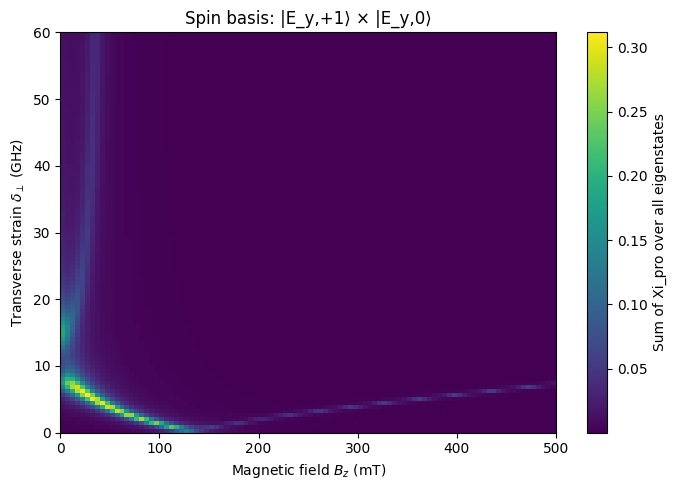

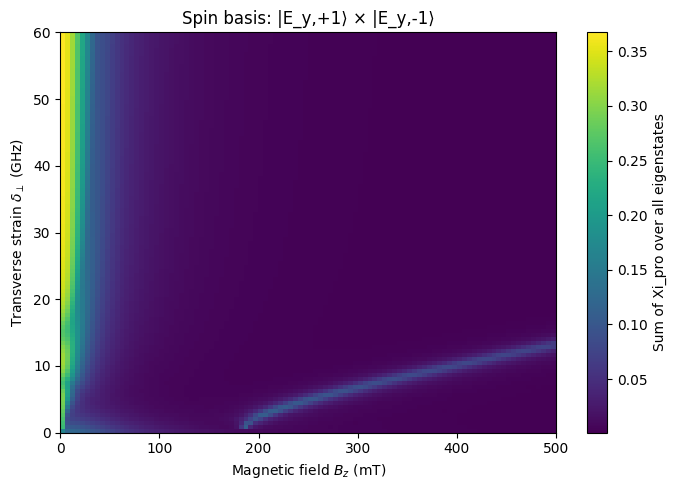

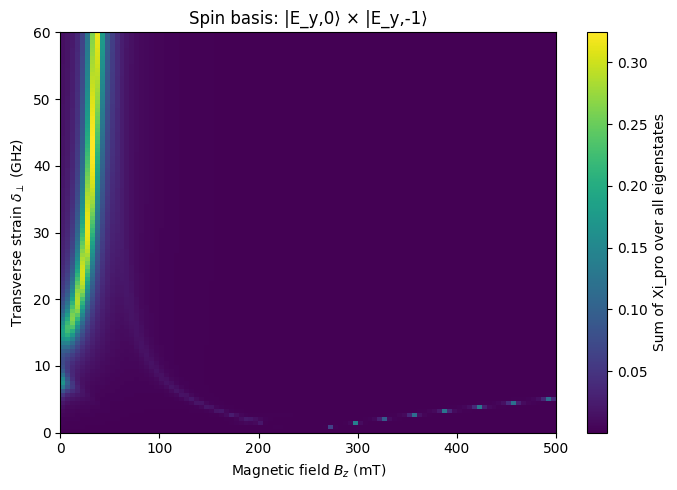

In [9]:
# 各ペアに対して処理
for i, j in combinations(range(6), 2):
    score_map = np.zeros((len(strain_perp_values), len(Bz_values)))

    for k, strain_perp in enumerate(strain_perp_values):
        deltax = deltay = strain_perp / np.sqrt(2) / des_perp
        delta = [deltax, deltay, 0]

        for w, Bz in enumerate(Bz_values):
            B = [0, 0, Bz]
            H_tot = H_es + V_es(E, B, delta)
            amp_matrix = Decomposition(H_tot)  # 各固有状態ごとの振幅 (6 × 6 matrix)

            score = 0.0
            for state in amp_matrix:  # 各固有状態に対して
                a_i = abs(state[i])**2
                a_j = abs(state[j])**2
                xi = a_i * a_j
                score += xi

            score_map[k, w] = score

    # 描画
    plt.figure(figsize=(7, 5))
    plt.imshow(score_map,
               extent=[Bz_values[0]*1e3, Bz_values[-1]*1e3,
                       strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9],
               origin='lower', aspect='auto', cmap='viridis')
    
    plt.colorbar(label='Sum of Xi_pro over all eigenstates')
    plt.xlabel('Magnetic field $B_z$ (mT)')
    plt.ylabel('Transverse strain $\delta_\perp$ (GHz)')
    plt.title(f'Spin basis: {spin_basis_labels[i]} × {spin_basis_labels[j]}')
    plt.tight_layout()
    plt.show()

In [8]:
# メッシュグリッド定義
strain_perp_values = np.linspace(0, 60e9, 100)  # Hz
Bz_values = np.linspace(0, 5000e-4, 100)        # T
E = [0, 0, 0]

In [10]:
# === 計算＋プロット関数 ===
def map_spin_basis_pair(i, j, strain_perp_values, Bz_values):
    """
    スピン基底ペア (i, j) に対する Xi_pro の合計スコアマップをプロット。
    """
    score_map = np.zeros((len(strain_perp_values), len(Bz_values)))

    for k, strain_perp in enumerate(strain_perp_values):
        deltax = deltay = strain_perp / np.sqrt(2) / des_perp
        delta = [deltax, deltay, 0]

        for w, Bz in enumerate(Bz_values):
            B = [0, 0, Bz]
            H_tot = H_es + V_es(E, B, delta)
            amp_matrix = Decomposition(H_tot)

            score = 0.0
            for state in amp_matrix:  # 各固有状態に対して
                a_i = abs(state[i])**2
                a_j = abs(state[j])**2
                xi = a_i * a_j
                score += xi

            score_map[k, w] = score

    # === 描画 ===
    plt.figure(figsize=(7, 5))
    plt.imshow(score_map,
               extent=[Bz_values[0]*1e3, Bz_values[-1]*1e3,
                       strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9],
               origin='lower', aspect='auto', cmap='viridis')
    
    plt.colorbar(label='Sum of Xi_pro over all eigenstates')
    plt.xlabel('Magnetic field $B_z$ (mT)')
    plt.ylabel('Transverse strain $\delta_\perp$ (GHz)')
    plt.title(f'Spin basis: {spin_basis_labels[i]} × {spin_basis_labels[j]}')
    plt.tight_layout()
    plt.show()


<>:35: SyntaxWarning: invalid escape sequence '\d'
<>:35: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_5824\3485146300.py:35: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('Transverse strain $\delta_\perp$ (GHz)')


In [40]:
def map_spin_basis_pair_Xi(i, j, strain_perp_values, Bz_values):
    """
    スピン基底ペア (i, j) に対する Xi の合計スコアマップをプロット。
    Xi = |a_i - a_j| / (|a_i| + |a_j|) を全固有状態について合計。
    """
    score_map = np.zeros((len(strain_perp_values), len(Bz_values)))

    for k, strain_perp in enumerate(strain_perp_values):
        deltax = deltay = strain_perp / np.sqrt(2) / des_perp
        delta = [deltax, deltay, 0]

        for w, Bz in enumerate(Bz_values):
            B = [0, 0, Bz]
            H_tot = H_es + V_es(E, B, delta)
            amp_matrix = Decomposition(H_tot)

            score = 0.0
            for state in amp_matrix:
                a_i = abs(state[i])
                a_j = abs(state[j])
                # if abs(a_i) - abs(a_j) > 1e-6:
                #     score += 1 / abs(a_i) - abs(a_j)
                # else:
                #     score += 1/1e-6  # どちらもゼロならスコアゼロ
                score += (abs(a_i)+abs(a_j)) / abs(abs(a_i)-abs(a_j))
                

            score_map[k, w] = score

    # === 描画 ===
    plt.figure(figsize=(7, 5))
    plt.imshow(score_map,
               extent=[Bz_values[0]*1e3, Bz_values[-1]*1e3,
                       strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9],
               origin='lower', aspect='auto', cmap='viridis')  # 色はお好みで変更可能
    
    plt.colorbar(label='Sum of Xi over all eigenstates')
    plt.xlabel('Magnetic field $B_z$ (mT)')
    plt.ylabel('Transverse strain $\delta_\perp$ (GHz)')
    plt.title(f'Spin basis: {spin_basis_labels[i]} × {spin_basis_labels[j]}')
    plt.tight_layout()
    plt.show()


<>:39: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_5824\1351993537.py:39: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('Transverse strain $\delta_\perp$ (GHz)')


C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_5824\3485146300.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = score


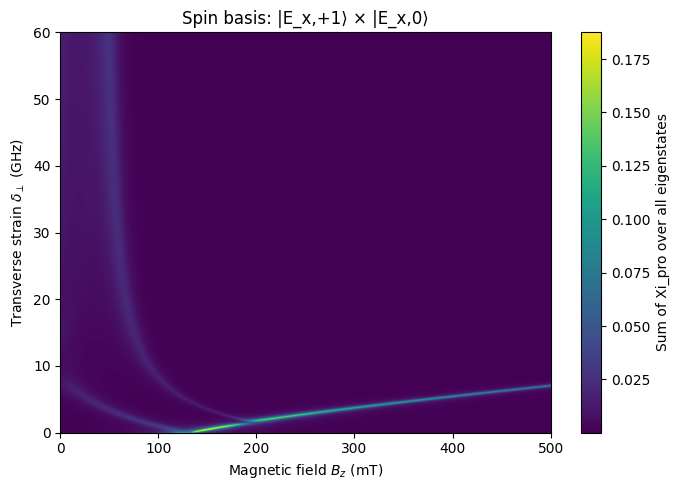

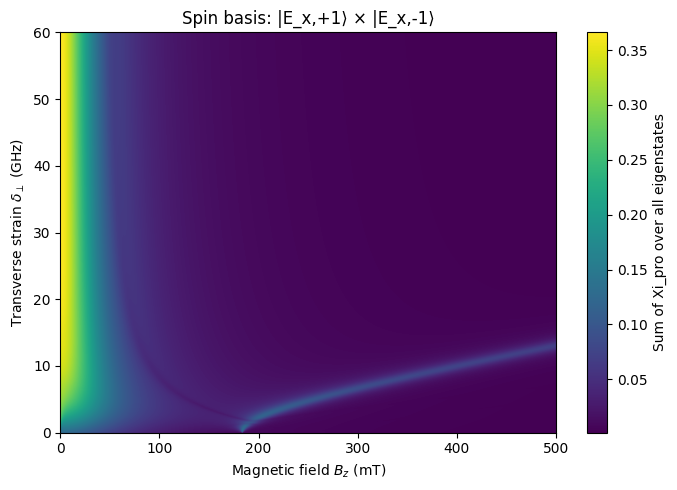

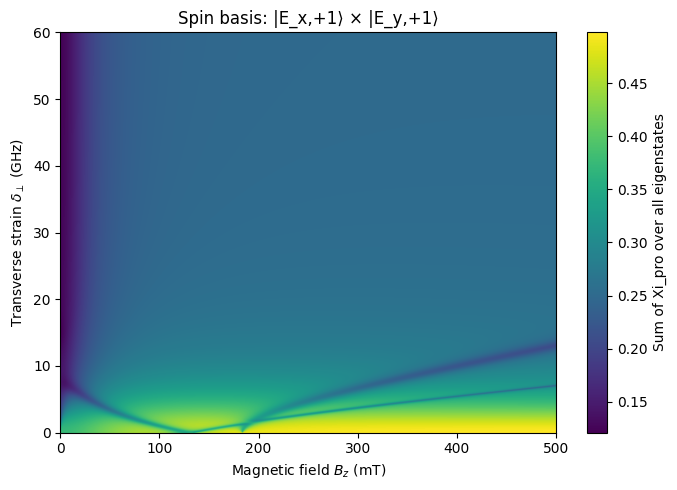

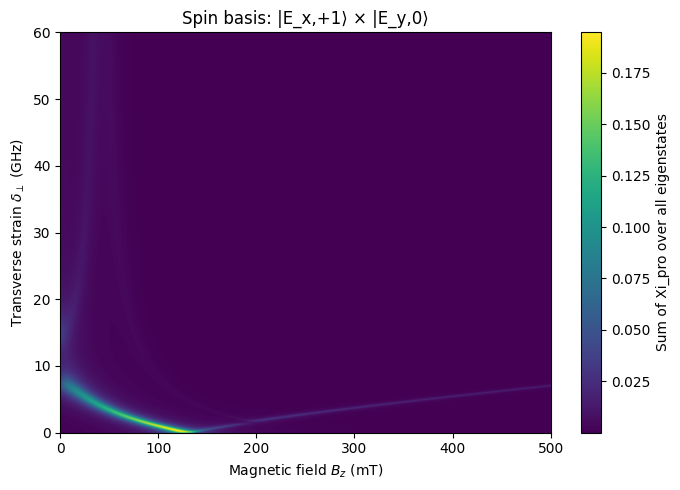

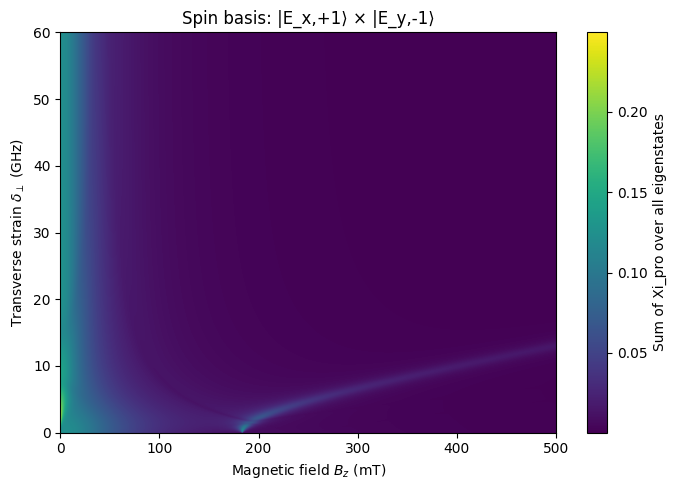

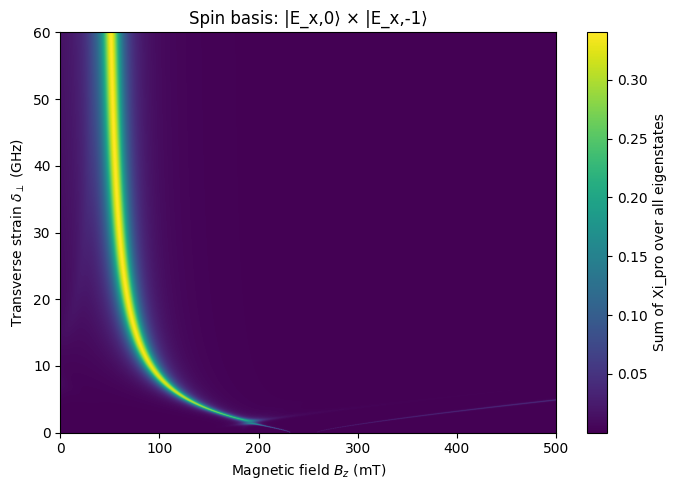

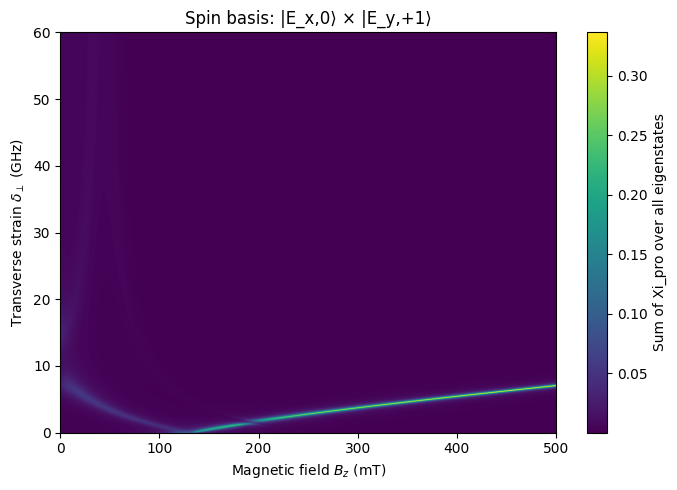

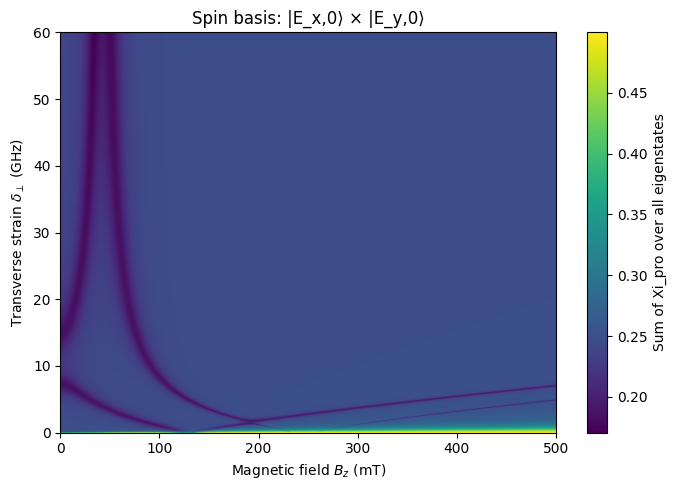

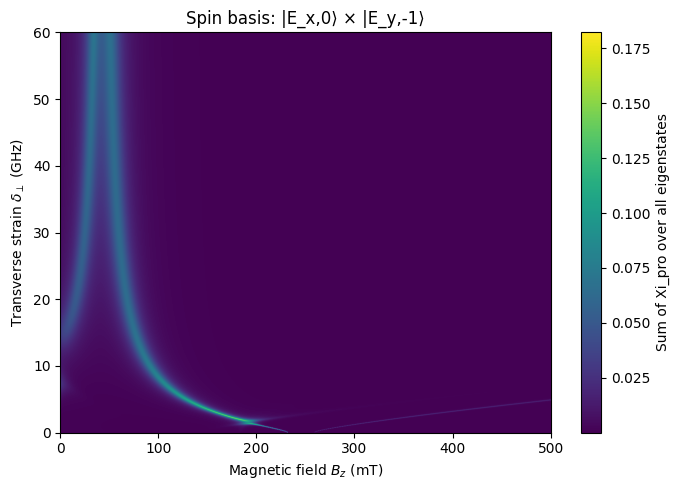

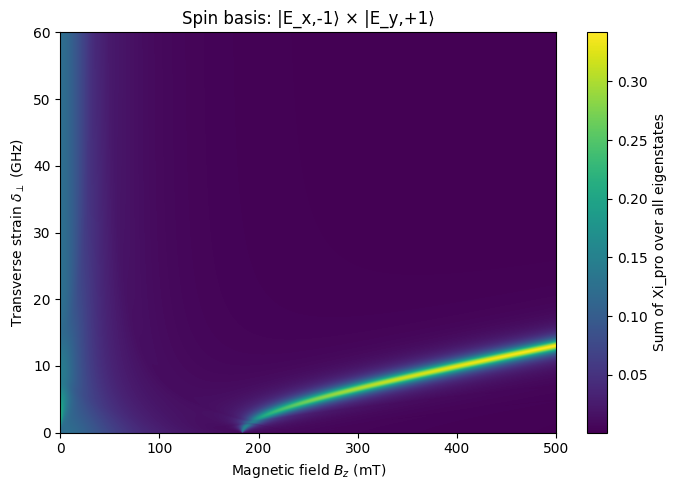

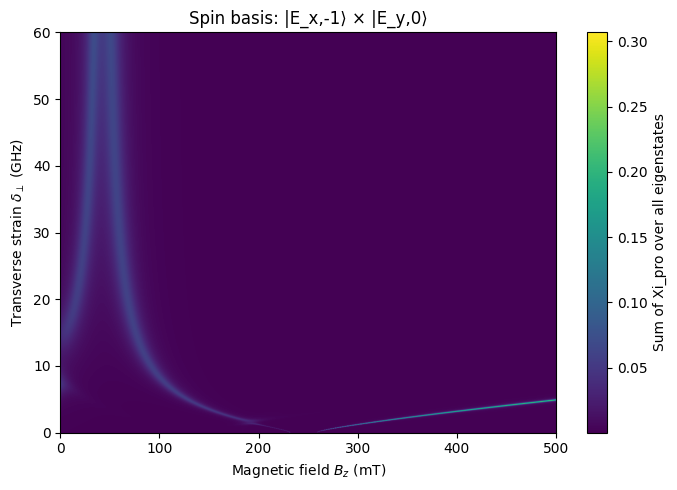

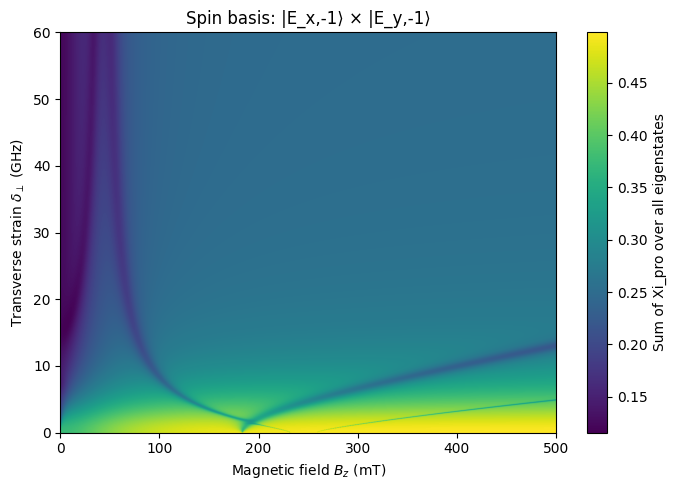

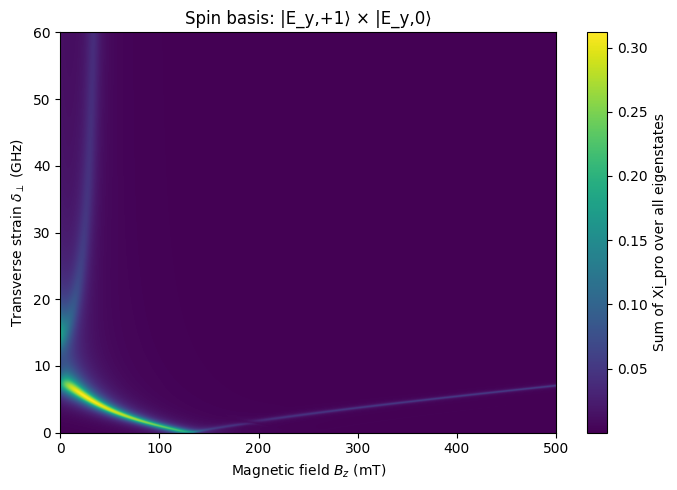

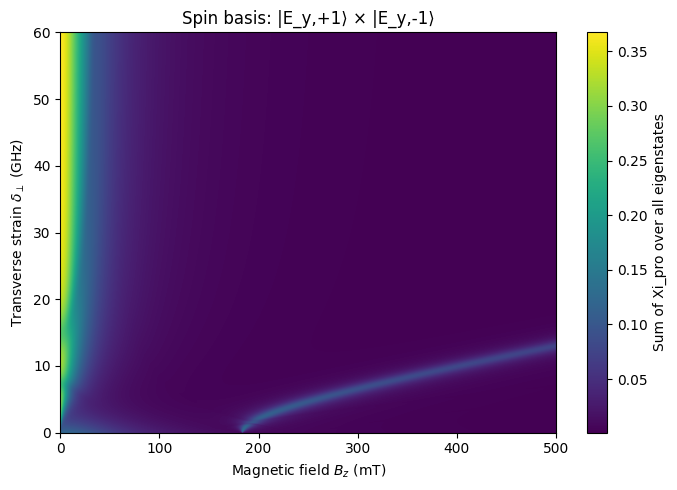

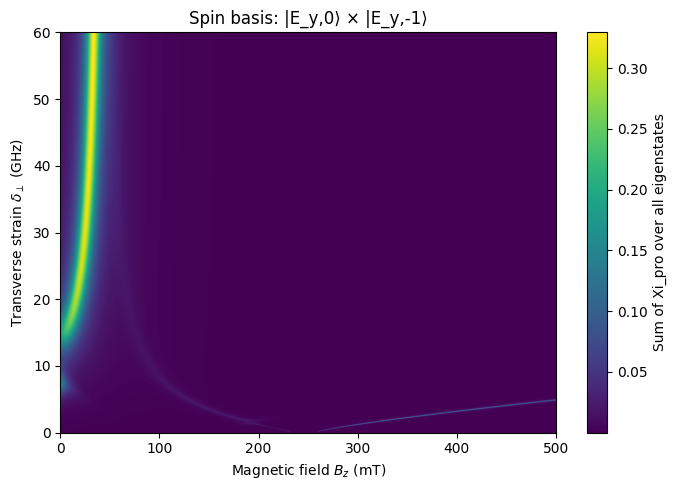

In [43]:

# メッシュ設定
strain_perp_values = np.linspace(0, 60e9, 1000)
Bz_values = np.linspace(0, 5000e-4, 1000)

# 全通り計算
for i, j in combinations(range(6), 2):
    map_spin_basis_pair(i, j, strain_perp_values, Bz_values)

In [8]:
def map_spin_basis_combined(pairs, strain_perp_values, Bz_values, show=True):

    total_score_map = np.zeros((len(strain_perp_values), len(Bz_values)))

    for i, j in pairs:
        score_map = np.zeros_like(total_score_map)

        for k, strain_perp in enumerate(strain_perp_values):
            deltax = deltay = strain_perp / np.sqrt(2) / des_perp
            delta = [deltax, deltay, 0]

            for w, Bz in enumerate(Bz_values):
                B = [0, 0, Bz]
                H_tot = H_es + V_es(E, B, delta)
                amp_matrix = Decomposition(H_tot)

                score = 0.0
                for state in amp_matrix:
                    a_i = abs(state[i])**2
                    a_j = abs(state[j])**2
                    score += a_i * a_j

                score_map[k, w] = score

        total_score_map += score_map

    if show:
        plt.figure(figsize=(7, 5))
        plt.imshow(total_score_map,
                   extent=[Bz_values[0]*1e3, Bz_values[-1]*1e3,
                           strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9],
                   origin='lower', aspect='auto', cmap='viridis')
        plt.colorbar(label='Total sum of Xi_pro over all eigenstates and pairs')
        plt.xlabel('Magnetic field $B_z$ (mT)')
        plt.ylabel('Transverse strain $\delta_\perp$ (GHz)')

        # タイトル短縮表示（|0>×|1>など）
        title_str = " + ".join([f"|{i}>×|{j}>" for i, j in pairs])
        plt.title(f"Combined Xi_pro for: {title_str}", fontsize=10)

        # 凡例風ラベル（spin_basis_labelsの定義がある前提）
        legend_text = "\n".join([f"|{i}> ≡ {spin_basis_labels[i]}" for i in sorted(set([idx for pair in pairs for idx in pair]))])
        plt.gcf().text(1.02, 0.5, legend_text, fontsize=9, va='center')  # 右側に配置

        plt.tight_layout()
        plt.show()

    return total_score_map


C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_5824\762775420.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = score


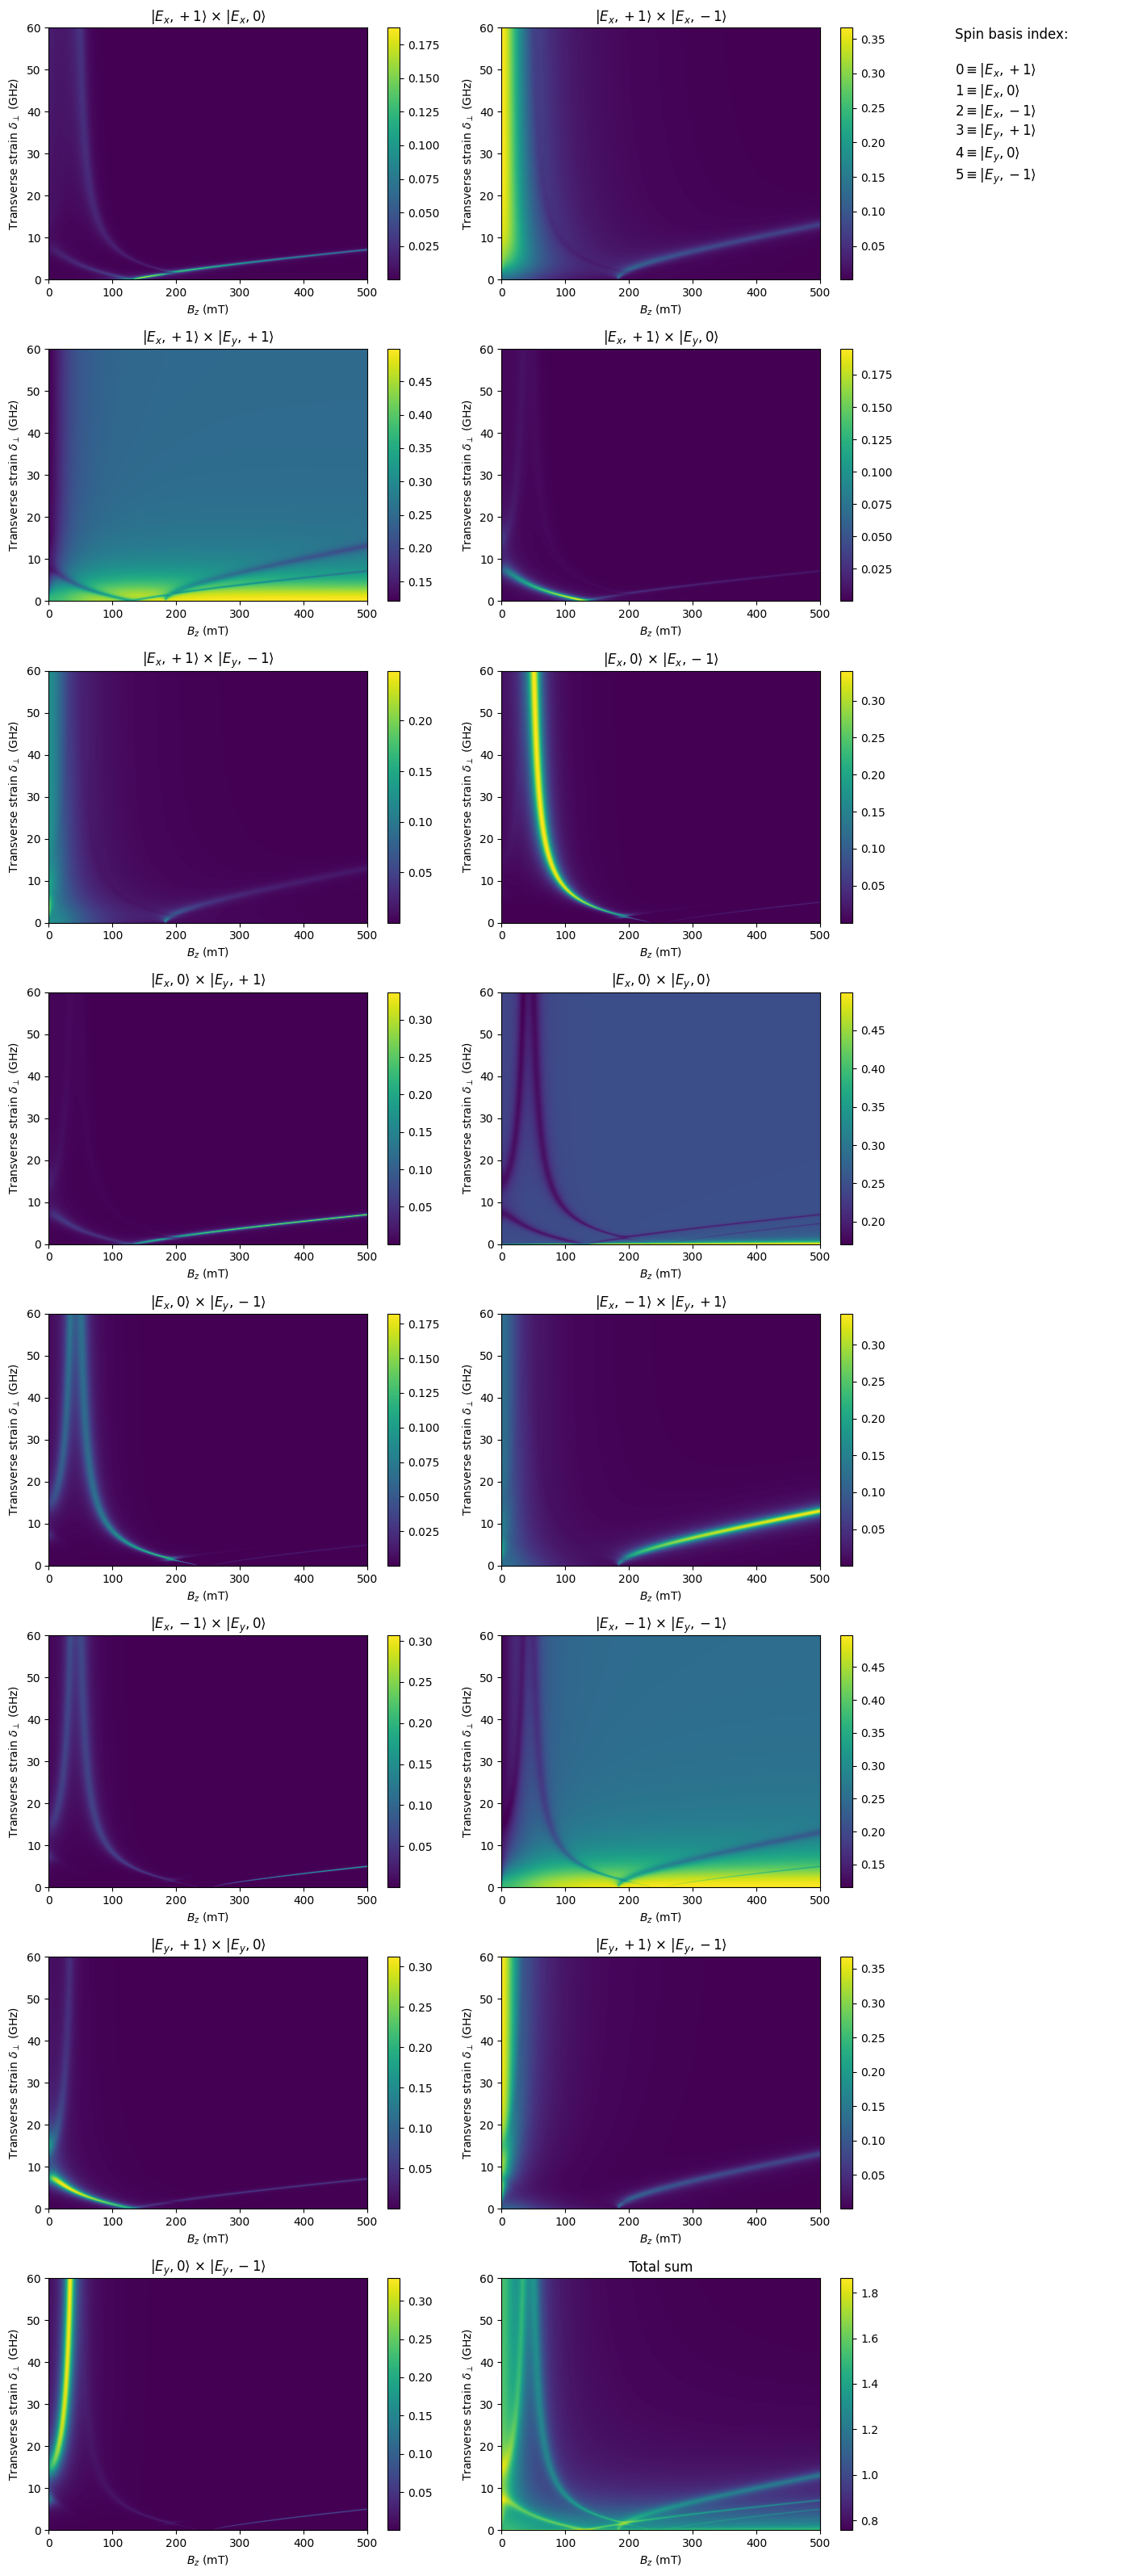

KeyboardInterrupt: 

In [ ]:
strain_perp_values = np.linspace(0, 60e9, 1000)
Bz_values = np.linspace(0, 5000e-4, 1000)

all_pairs = list(combinations(range(6), 2))
# selected_pairs = [(4, 5), (1, 2), (3, 4), (1,3), (2,4)]
map_spin_basis_combined(all_pairs, strain_perp_values, Bz_values)
# map_spin_basis_combined(selected_pairs, strain_perp_values, Bz_values)

C:\Users\risei\AppData\Local\Temp\ipykernel_9576\762775420.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = score


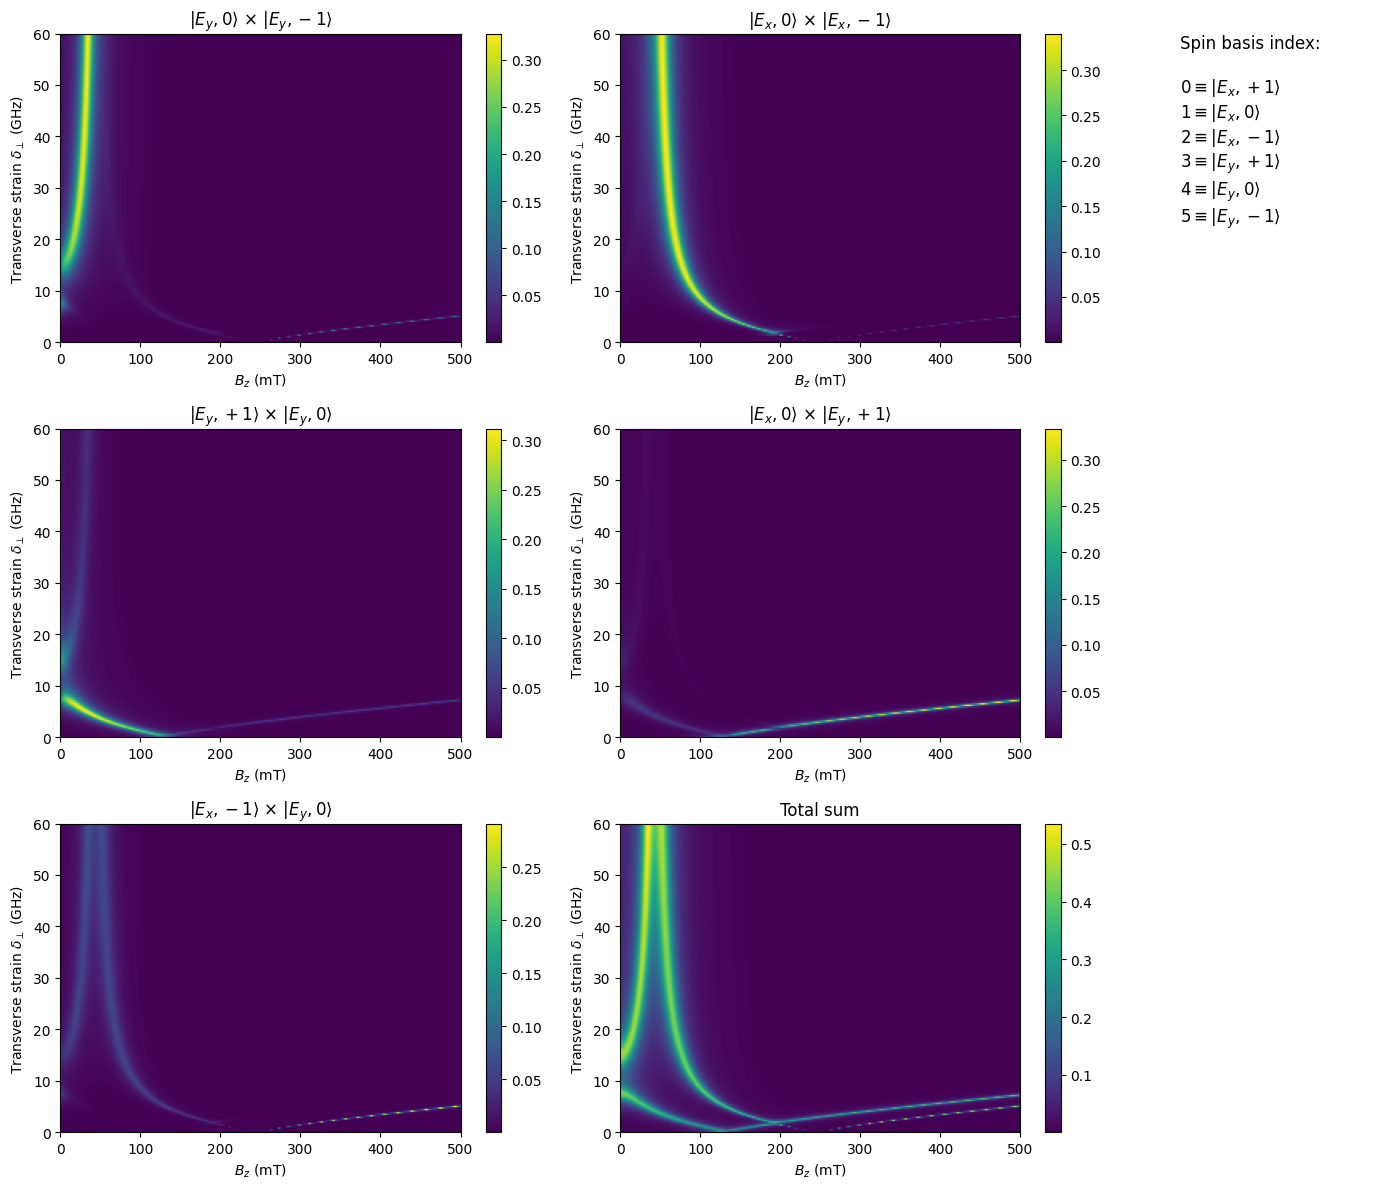

In [11]:
E = [0,0,0]
strain_perp_values = np.linspace(0, 60e9, 200)
Bz_values = np.linspace(0, 5000e-4, 200)
selected_pairs = [(4, 5), (1, 2), (3, 4), (1,3), (2,4)]
map_spin_basis_combined(selected_pairs, strain_perp_values, Bz_values)


In [9]:
def map_spin_basis_combined(
    pairs,
    strain_perp_values,
    Bz_values
):
    import matplotlib.gridspec as gridspec

    spin_basis_labels = [
        r"$|E_x,+1\rangle$", r"$|E_x,0\rangle$", r"$|E_x,-1\rangle$",
        r"$|E_y,+1\rangle$", r"$|E_y,0\rangle$", r"$|E_y,-1\rangle$"
    ]

    score_maps = []
    titles = []

    for i, j in pairs:
        score_map = np.zeros((len(strain_perp_values), len(Bz_values)))

        for k, strain_perp in enumerate(strain_perp_values):
            deltax = deltay = strain_perp / np.sqrt(2) / des_perp
            delta = [deltax, deltay, 0]

            for w, Bz in enumerate(Bz_values):
                B = [0, 0, Bz]
                H_tot = H_es + V_es(E, B, delta)
                amp_matrix = Decomposition(H_tot)

                score = 0.0
                for state in amp_matrix:
                    a_i = abs(state[i])**2
                    a_j = abs(state[j])**2
                    score += a_i * a_j

                score_map[k, w] = score

        score_maps.append(score_map)
        titles.append(f"{spin_basis_labels[i]} × {spin_basis_labels[j]}")

    total_map = np.sum(score_maps, axis=0)
    score_maps.append(total_map)
    titles.append("Total sum")

    # === Layout parameters ===
    n_plots = len(score_maps)
    n_cols = 2  # limit to 2 columns
    n_rows = int(np.ceil(n_plots / n_cols))

    fig = plt.figure(figsize=(6 * n_cols + 2, 4 * n_rows))
    gs = gridspec.GridSpec(n_rows, n_cols + 1, width_ratios=[1]*n_cols + [0.4], figure=fig)

    for idx, (score_map, title) in enumerate(zip(score_maps, titles)):
        row = idx // n_cols
        col = idx % n_cols
        ax = fig.add_subplot(gs[row, col])

        im = ax.imshow(
            score_map,
            extent=[Bz_values[0]*1e3, Bz_values[-1]*1e3,
                    strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9],
            origin='lower', aspect='auto', cmap='viridis'
        )
        ax.set_title(title)
        ax.set_xlabel(r"$B_z$ (mT)")
        ax.set_ylabel(r"Transverse strain $\delta_\perp$ (GHz)")
        fig.colorbar(im, ax=ax)

    # 凡例エリア
    ax_legend = fig.add_subplot(gs[:, -1])
    ax_legend.axis('off')
    legend_text = "\n".join([
        r"$0 \equiv |E_x,+1\rangle$", r"$1 \equiv |E_x,0\rangle$",
        r"$2 \equiv |E_x,-1\rangle$", r"$3 \equiv |E_y,+1\rangle$",
        r"$4 \equiv |E_y,0\rangle$", r"$5 \equiv |E_y,-1\rangle$"
    ])
    ax_legend.text(0, 1, "Spin basis index:\n\n" + legend_text,
                   va='top', ha='left', fontsize=12)

    plt.tight_layout()
    plt.show()


In [12]:
strain_perp_values = np.linspace(0, 60e9, 1000)
Bz_values = np.linspace(0, 5000e-4, 1000)
selected_pairs = [(4, 5), (1, 2), (3, 4), (1,3), (2,4)]
map_spin_basis_combined(selected_pairs, strain_perp_values, Bz_values)


C:\Users\risei\AppData\Local\Temp\ipykernel_18132\1639918658.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = score


KeyboardInterrupt: 

In [13]:
def map_spin_basis_combined(
    pairs,
    strain_perp_values,
    Bz_values
):
    import matplotlib.gridspec as gridspec

  

    score_maps = []
    titles = []

    for i, j in pairs:
        score_map = np.zeros((len(strain_perp_values), len(Bz_values)))

        for k, strain_perp in enumerate(strain_perp_values):
            deltax = deltay = strain_perp / np.sqrt(2) / des_perp
            delta = [deltax, deltay, 0]

            for w, Bz in enumerate(Bz_values):
                B = [0, 0, Bz]
                H_tot = H_es + V_es(E, B, delta)
                amp_matrix = Decomposition(H_tot)

                score = 0.0
                for state in amp_matrix:
                    a_i = abs(state[i])**2
                    a_j = abs(state[j])**2
                    score += a_i * a_j

                score_map[k, w] = score

        score_maps.append(score_map)
        

    total_map = np.sum(score_maps, axis=0)
    score_maps.append(total_map)
    titles.append("Total sum")

     
    plt.figure(figsize=(7, 5))
    plt.imshow(total_map,
                   extent=[Bz_values[0]*1e3, Bz_values[-1]*1e3,
                           strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9],
                   origin='lower', aspect='auto', cmap='viridis')
    plt.colorbar(label='Total sum of Xi_pro over all eigenstates and pairs')
    plt.xlabel('Magnetic field $B_z$ (mT)')
    plt.ylabel('Transverse strain $\delta_\perp$ (GHz)')
   
    plt.tight_layout()
    plt.show()


C:\Users\risei\AppData\Local\Temp\ipykernel_18132\3338485643.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = score


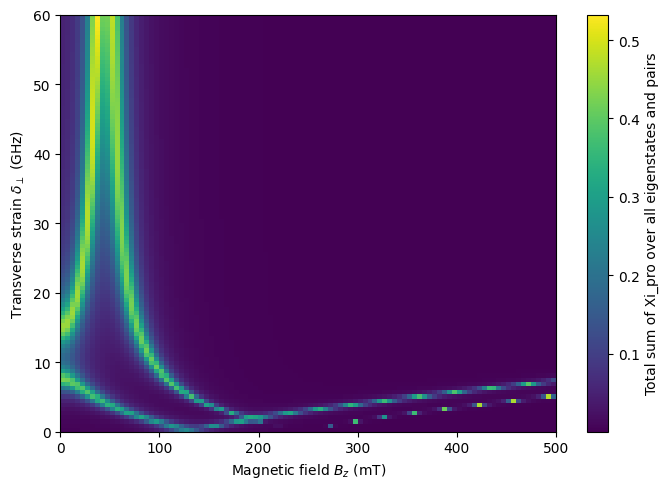

In [15]:
strain_perp_values = np.linspace(0, 60e9, 100)
Bz_values = np.linspace(0, 5000e-4, 100)
selected_pairs = [(4, 5), (1, 2), (3, 4), (1,3), (2,4)]
map_spin_basis_combined(selected_pairs, strain_perp_values, Bz_values)

# 2025 7/10

How does the map changed by $B_{para}$

$B_{para} = \sqrt{B_x^2 + B_y^2}$


In [44]:
def map_spin_basis_combined_B_para(
    pairs,
    strain_perp_values,
    Bz_values
):
    import matplotlib.gridspec as gridspec


    B_para_list = [0e-4,10e-4,100e-4,1000e-4]
    B_index = 0

    score_maps = []
    titles = []
    for B_para in B_para_list:
        score_sum = []
        
        
        
        for i, j in pairs:
            score_map = np.zeros((len(strain_perp_values), len(Bz_values)))
            

            for k, strain_perp in enumerate(strain_perp_values):
                deltax = deltay = strain_perp / np.sqrt(2) / des_perp
                delta = [deltax, deltay, 0]

                for w, Bz in enumerate(Bz_values):
                    Bx = By = B_para / np.sqrt(2) /ges_perp
                    B = [Bx, By, Bz]
                    H_tot = H_es + V_es(E, B, delta)
                    amp_matrix = Decomposition(H_tot)

                    score = 0.0
                    for state in amp_matrix:
                        a_i = abs(state[i])**2
                        a_j = abs(state[j])**2
                        score += a_i * a_j

                    score_map[k, w] = score

            score_sum.append(score_map)
            

        total_map = np.sum(score_sum, axis=0)
        score_maps.append(total_map)
        titles.append(f"Total sum ({B_para_list[B_index] *1e3} [mT])" )
        B_index +=1

# === Layout parameters ===
    n_plots = len(score_maps)
    n_cols = 2  # limit to 2 columns
    n_rows = int(np.ceil(n_plots / n_cols))

    fig = plt.figure(figsize=(6 * n_cols + 2, 4 * n_rows))
    gs = gridspec.GridSpec(n_rows, n_cols + 1, width_ratios=[1]*n_cols + [0.4], figure=fig)

    for idx, (score_map, title) in enumerate(zip(score_maps, titles)):
        row = idx // n_cols
        col = idx % n_cols
        ax = fig.add_subplot(gs[row, col])

        im = ax.imshow(
            score_map,
            extent=[Bz_values[0]*1e3, Bz_values[-1]*1e3,
                    strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9],
            origin='lower', aspect='auto', cmap='viridis'
        )
        ax.set_title(title)
        ax.set_xlabel(r"$B_z$ (mT)")
        ax.set_ylabel(r"Transverse strain $\delta_\perp$ (GHz)")
        fig.colorbar(im, ax=ax)

  

    plt.tight_layout()
    plt.show()


   
 


        


C:\Users\risei\AppData\Local\Temp\ipykernel_18132\716327353.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = score


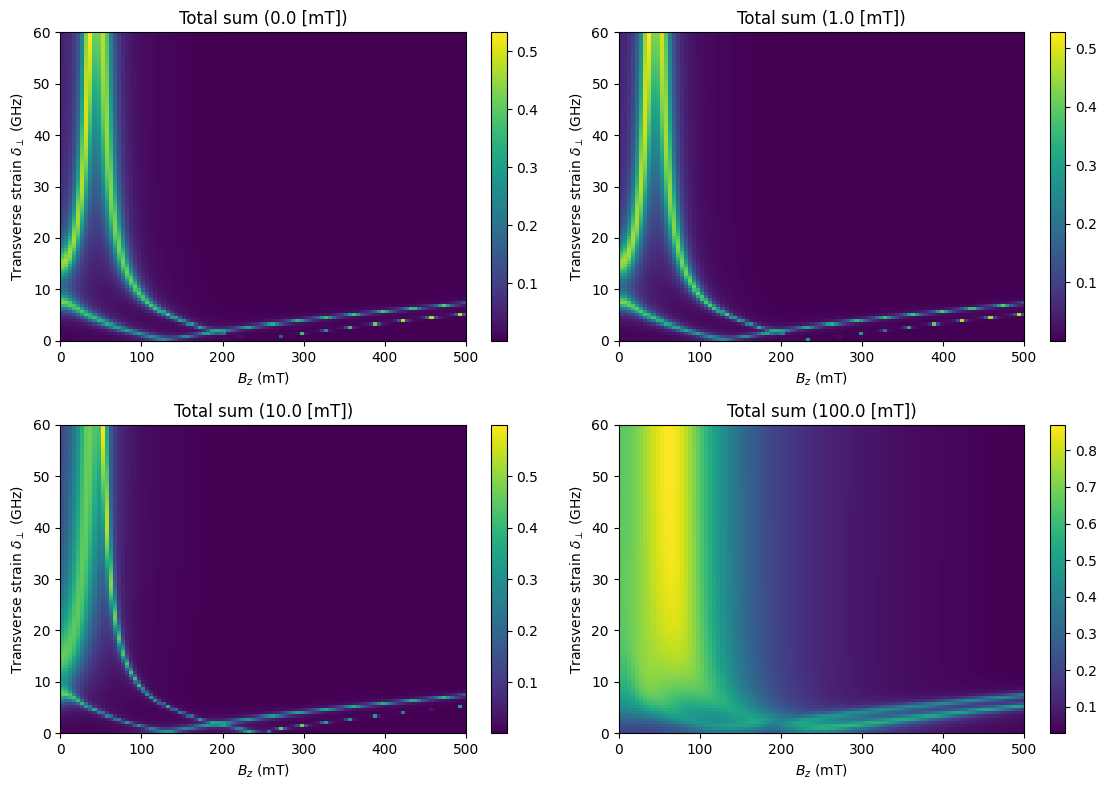

In [46]:
E = [0,0,0]
strain_perp_values = np.linspace(0, 60e9, 100)
Bz_values = np.linspace(0, 5000e-4, 100)
selected_pairs = [(4, 5), (1, 2), (3, 4), (1,3), (2,4)]

map_spin_basis_combined_B_para(selected_pairs, strain_perp_values, Bz_values)

下記はsanity check用の関数


In [ ]:
def map_spin_basis_combined_sanity(
    pairs,
    strain_perp_values,
    Bz_values
):
    import matplotlib.gridspec as gridspec

  

    score_maps = []
    titles = []

    for i, j in pairs:
        score_map = np.zeros((len(strain_perp_values), len(Bz_values)))

        for k, strain_perp in enumerate(strain_perp_values):
            deltax = deltay = strain_perp / np.sqrt(2) / des_perp
            delta = [deltax, deltay, 0]

            for w, Bz in enumerate(Bz_values):
                B = [0, 0, Bz]
                H_tot = H_es + V_es(E, B, delta)
                amp_matrix = Decomposition(H_tot)

                score = 0.0
                for state in amp_matrix:
                    a_i = abs(state[i])**2
                    a_j = abs(state[j])**2
                    score += a_i * a_j

                score_map[k, w] = score

        score_maps.append(score_map)
        

    total_map = np.sum(score_maps, axis=0)
    score_maps.append(total_map)
    titles.append("Total sum")

     
    plt.figure(figsize=(7, 5))
    plt.imshow(total_map,
                   extent=[Bz_values[0]*1e3, Bz_values[-1]*1e3,
                           strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9],
                   origin='lower', aspect='auto', cmap='viridis')
    plt.colorbar(label='Total sum of Xi_pro over all eigenstates and pairs')
    plt.xlabel('Magnetic field $B_z$ (mT)')
    plt.ylabel('Transverse strain $\delta_\perp$ (GHz)')
   
    plt.tight_layout()
    plt.show()
